# Assignment 3: Non-Linear Models and Validation Metrics (52 marks total)
### Due: March 6 at 11:59pm

### Name:

### In this assignment, you will need to write code that uses non-linear models to perform classification and regression tasks. You will also be asked to describe the process by which you came up with the code. More details can be found below. Please cite any websites or AI tools that you used to help you with this assignment.

## Part 1: Classification (30 marks)

### *Part 1A: Decision Function*

Building on the first part of the previous assignment, we would like to test how changing the decision boundary for a linear model impacts the results.

### Step 0: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore') #ignoring some deprication warnings

### Step 1: Data Input (1 mark)

Load data using the same method as assignment 2.

In [3]:
# TO DO: Import spam dataset from yellowbrick library
from yellowbrick.datasets import load_spam

X, y = load_spam()
print(f"Dimensions of X (Features): {X.shape}")
print(f"Dimensions of y (Target): {y.shape}")

Dimensions of X (Features): (4600, 57)
Dimensions of y (Target): (4600,)


Next, we need to split the data into training and testing sets.

In [4]:
# TO DO: Split 10% of the data for the testing set (1 mark)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=0)

### Step 2: Data Processing (1 mark)
Based on assignment 2, follow the same data processing steps (if needed). You can also use `describe()` to check the range of each feature (will be used later).

In [5]:
# TO DO: Data processing steps (if needed)
null_counts_X = X.isnull().sum().sum()
null_counts_y = y.isnull().sum()

print(f"Total missing values in X: {null_counts_X}")
print(f"Total missing values in y: {null_counts_y}")

Total missing values in X: 0
Total missing values in y: 0


In [6]:
# TO DO: Check the feature ranges (1 mark)
df = pd.DataFrame(X)

feature_ranges = df.describe()
print(feature_ranges)

       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4600.000000        4600.000000    4600.000000   4600.000000   
mean         0.104576           0.212922       0.280578      0.065439   
std          0.305387           1.290700       0.504170      1.395303   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.000000           0.000000       0.000000      0.000000   
75%          0.000000           0.000000       0.420000      0.000000   
max          4.540000          14.280000       5.100000     42.810000   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count    4600.000000     4600.000000       4600.000000         4600.000000   
mean        0.312222        0.095922          0.114233            0.105317   
std         0.672586        0.273850          0.391480            0.401112   
min         0.000000        0.

### Step 3: Implement Machine Learning Model (2 marks)

1. Import `LogisticRegression` from sklearn
1. Instantiate model `LogisticRegression(max_iter=2000)`
1. Split training data into training and validation sets (use 20% of the data for validation and use stratify)
1. Train the machine learning model

In [7]:
# TO DO: Split training data into training and validation sets and fit model to training data (2 marks)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=0)

model.fit(X_train2, y_train2)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


### Step 4-5: Validate Model and Visualize Results (4 marks)

Next, we can print the classification report and confusion matrix for this data set using the training and validation data.

In [8]:
# TO DO: Print classification report (1 mark)
from sklearn.metrics import classification_report

y_val_pred = model.predict(X_val)
cr = classification_report(y_val, y_val_pred)

print(cr)

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       507
           1       0.90      0.90      0.90       321

    accuracy                           0.92       828
   macro avg       0.92      0.92      0.92       828
weighted avg       0.92      0.92      0.92       828



In [9]:
# TO DO: Print confusion matrix (1 mark)
from sklearn.metrics import confusion_matrix

y_val_pred = model.predict(X_val)
cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[474  33]
 [ 32 289]]


In this case, do we want to increase precision or recall? Based on your choice, select the appropriate direction to adjust the decision boundary. You can use either 0.8 or -0.8 as your new threshold, depending on your selected direction.

In [10]:
# TO DO: Predict values based on new decision function threshold and print classification report (1 mark)
decision_scores = model.decision_function(X_val)

y_val_pred_new = (decision_scores > 0.8).astype(int)
cr = classification_report(y_val, y_val_pred_new)

print(cr)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       507
           1       0.91      0.86      0.88       321

    accuracy                           0.91       828
   macro avg       0.91      0.90      0.91       828
weighted avg       0.91      0.91      0.91       828



In [11]:
# TO DO: Print new confusion matrix (1 mark)
decision_scores = model.decision_function(X_val)

y_val_pred_new = (decision_scores > 0.8).astype(int)
cm = confusion_matrix(y_val, y_val_pred_new)

print(cm)

[[481  26]
 [ 46 275]]


### Questions (6 marks)
1. Did you decide to move the threshold to increase recall or precision? Why? Which direction did you choose to accomplish this?
1. How did your decision impact the number of false negatives and false positives? What is a potential unintended consequence of changing the decision boundary in this context?
1. Why did we use the validation data instead of the test data to check the new decision threshold?

*ANSWER HERE*
1. I decided to increase precision, because as discussed in Assignment 2, in spam filtering, false positives are usually more harmful than false negatives because legitimate emails may be lost or never seen by the user. I did this by raising the decision threshold to 0.8.
2. My decision resulted in false positives decreasing from 33 to 26 and false negatives increasing from 32 to 46. And by increasing precision, I'm risking missing more actual spam messages. This means more spam slips into the inbox.
3. The validation dataset was used because we are tuning a hyperparameter, in this case, the decision function.

### *Part 1B: Non-linear classification*

Using the spam dataset from part 1A, compare the performance of two non-linear models to the linear model used in assignment 2.

### Step 3: Implement Machine Learning Models

1. Import `LogisticRegression`, `KNeighborsClassifier` and `RandomForestClassifier` from sklearn
2. Instantiate models as `LogisticRegression(max_iter=2000)`, `KNeighborsClassifier(n_neighbors=3)` and `RandomForestClassifier(random_state=0, max_depth=10)`
3. Implement the machine learning models

### Step 4: Validate Model

Calculate the training and validation accuracy for the three different models mentioned in Step 3. For this case, you can use `cross_validate()` with `cv=5` and `scoring='accuracy'` to get the training and validation data for each of the three models and calculate the accuracy results.

### Step 5.1: Visualize Results (3 marks)

1. Create a pandas DataFrame `results` with columns: Training accuracy and Validation accuracy
1. Add the training accuracy and validation accuracy for each model to the `results` DataFrame
1. Add the model names as the index for the DataFrame
1. Print `results`

In [12]:
# TO DO: ADD YOUR CODE HERE FOR STEPS 3-5
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
# HINT: USING A LOOP TO STORE THE DATA IN YOUR RESULTS DATAFRAME WILL BE MORE EFFICIENT

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Random Forest (depth=10)": RandomForestClassifier(random_state=0, max_depth=10)
}

results = pd.DataFrame(columns=["Training accuracy", "Validation accuracy"])

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        return_train_score=True
    )
    
    train_acc = cv_results['train_score'].mean()
    val_acc = cv_results['test_score'].mean()
    
    results.loc[name] = [train_acc, val_acc]

print(results)

                          Training accuracy  Validation accuracy
Logistic Regression                0.929167             0.923188
KNN (k=3)                          0.895229             0.795652
Random Forest (depth=10)           0.967754             0.942512


Which model gave us the best results? Use that model for the next section.

### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the classification report and confusion matrix to investigate the recall vs. precision for the best model. Use the full training set and testing set for this analysis.

In [13]:
# TO DO: Train model and find predicted values for testing set using best model (1 mark)
model = RandomForestClassifier(random_state=0, max_depth=10)
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)

In [14]:
# TO DO: Print classification report for test set (1 mark)
cr = classification_report(y_test, y_test_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       263
           1       0.97      0.93      0.95       197

    accuracy                           0.96       460
   macro avg       0.96      0.95      0.96       460
weighted avg       0.96      0.96      0.96       460



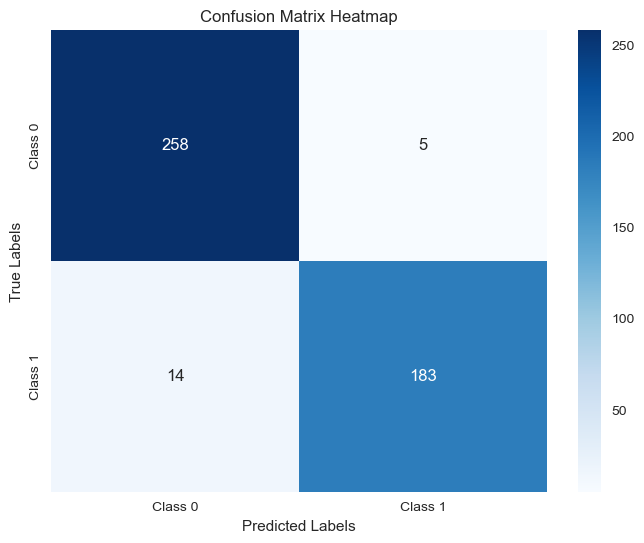

In [15]:
# TO DO: Print confusion matrix using a heatmap for test set (1 mark)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

### Questions (6 marks)
1. Which model did you select for part 5.2? How did it compare to the other models?
1. Looking at the feature ranges (from Part 1A), would a tree-based model or KNN make more sense for this dataset?
1. In your opinion, is it better to focus on changing the decision threshold or change the model to improve precision/recall results? Why?

*ANSWER HERE*
1. The strongest performer from part 5.2 was Random Forest with max_depth=10. Its validation accuracy was higher than both Logistic Regression and KNN, and its test‑set performance confirmed that it generalizes well. To compare: Random Forest had the best accuracies at (0.967754 training and 0.942512 validation), then Logistic Regression at (0.929167 training and 0.923188 validation), and lastly K-NN at (0.895229 training and 0.795652 validation).
2. The spam dataset contains 57 features, many of which have very different ranges. KNN relies on distance calculations, and when feature scales vary widely, distance becomes dominated by the largest‑range features unless explicit scaling is applied. Tree‑based models do not depend on distance metrics and split features independently, so they are naturally robust to differing feature ranges. Given the high dimensionality and uneven feature scales, a tree‑based model makes more sense for this dataset than KNN, which is more sensitive to scale and suffers in high‑dimensional spaces.
3. Adjusting the decision threshold is useful when you want to shift the balance between precision and recall for a fixed model, especially in cases like spam filtering where the cost of false positives and false negatives differs. However, threshold tuning cannot overcome the fundamental limitations of a model’s decision boundary. In my results, even after tuning the threshold, Logistic Regression could not match the precision and recall achieved by the Random Forest. Changing the model provides a deeper improvement because it changes the underlying capacity to capture non‑linear patterns, while threshold tuning only redistributes errors.

### Process Description (4 marks)
Please describe the process you used to create your code for parts A and B. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. The code is primarily my own. I wrote the implementation myself, however, I refined parts of it using general guidance from generative AI tools. I also drew inspiration from concepts and examples covered in previous courses and from sample materials posted on D2L.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. I used GenAI to refine my code where necessary, asking things like <i>`Can you help clean up or improve this code script?`</i>, and finally to fix the grammar in my written answers <i>`Can you fix the grammar in my answers without changing the tone or sentence structure?`</i>. I did need to slightly modify the generated code to better fit the structure of my notebook and match the variables I was already using.
4. I encountered no major challenges while completing this assignment. My success was due to extensive preparation for the midterm, which involved reviewing all lecture examples and practice notebooks provided in the course.

## Part 2: Regression (20 marks)

For this section, we will be using the auto-mpg dataset from assignment 2. You will need to repeat the steps from Part 1 for this analysis.

### Step 1: Data Input

The data used for this task can be downloaded from UCI website: https://archive.ics.uci.edu/ml/datasets/Auto%2BMPG

Load the auto-mpg dataset using the method from assignment 2.

In [16]:
# TO DO: Import auto-mpg data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

column_names = [
    'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 
    'acceleration', 'model year', 'origin', 'car name'
]

df = pd.read_csv(url, names=column_names, sep='\s+', na_values='?')
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


### Step 2: Data Processing (1 mark)

Follow the same processing steps as the previous assignment.

In [17]:
# TO DO: Process the data - fill-in any missing values and remove any non-numeric columns (0.5 marks)
missing_counts = df.isnull().sum()
print(missing_counts)

df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df_numeric = df.drop(columns=['car name'])

print(df_numeric.dtypes)
print(df_numeric.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model year        int64
origin            int64
dtype: object
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64


Split the auto-mpg data into the feature matrix and target vector. Inspect the first few columns of the feature matrix to make sure it split properly.

In [18]:
# TO DO: Create feature matrix and target vector (0.5 marks)
X = df_numeric.drop(columns=['mpg'])
y = df_numeric['mpg']

print("Feature Matrix (X) - First 5 rows:")
print(X.head())

print("\nTarget Vector (y) - First 5 rows:")
print(y.head())

Feature Matrix (X) - First 5 rows:
   cylinders  displacement  horsepower  weight  acceleration  model year  \
0          8         307.0       130.0  3504.0          12.0          70   
1          8         350.0       165.0  3693.0          11.5          70   
2          8         318.0       150.0  3436.0          11.0          70   
3          8         304.0       150.0  3433.0          12.0          70   
4          8         302.0       140.0  3449.0          10.5          70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  

Target Vector (y) - First 5 rows:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


### Step 3: Implement and Validate Machine Learning Model (6 marks)

1. Import any required libraries
1. Split the data into training and testing sets (testing data should be 10% of the dataset)
1. Train and validate the KNN and Decision Tree models with the training set (use `cross_validate()` with `cv=5` and `scoring='r2'`)
1. Test four different neighbours: 3, 5, 7 and 9, and five different max_depth values: 3, 5, 7, 9 and 11
1. Print the training and validation accuracy for the hyperparameter value that gave the best results for each model

**Note**: for any random state parameters, you can use random_state = 0

In [19]:
# TO DO: Split training and testing sets (1 mark)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=0)

In [20]:
# TO DO: Test n_neighbors of 3, 5, 7 and 9 for a KNN model to find the best results (1.5 marks)
from sklearn.neighbors import KNeighborsRegressor

# Hint: It is easier if you use a loop to evaluate each n_neighbors
k_values = [3, 5, 7, 9]
knn_results = {}

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    
    cv_results = cross_validate(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True
    )
    
    train_mean = cv_results['train_score'].mean()
    val_mean = cv_results['test_score'].mean()
    
    knn_results[k] = (train_mean, val_mean)
    
    print(f"K = {k}: Train R² = {train_mean:.4f}, Validation R² = {val_mean:.4f}")

K = 3: Train R² = 0.8560, Validation R² = 0.6589
K = 5: Train R² = 0.8132, Validation R² = 0.6804
K = 7: Train R² = 0.7861, Validation R² = 0.6891
K = 9: Train R² = 0.7691, Validation R² = 0.6889


In [21]:
# TO DO: Test max_depths of 3, 5, 7, 9 and 11 for a decision tree model to find the best results (1.5 marks)
from sklearn.tree import DecisionTreeRegressor

# Hint: It is easier if you use a loop to evaluate each max_depth
depth_values = [3, 5, 7, 9, 11]
dt_results = {}

for depth in depth_values:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=0)
    
    cv_results = cross_validate(
        dt,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True
    )
    
    train_mean = cv_results['train_score'].mean()
    val_mean = cv_results['test_score'].mean()
    
    dt_results[depth] = (train_mean, val_mean)
    
    print(f"max_depth = {depth}: Train R² = {train_mean:.4f}, Validation R² = {val_mean:.4f}")

max_depth = 3: Train R² = 0.8277, Validation R² = 0.7634
max_depth = 5: Train R² = 0.9252, Validation R² = 0.7518
max_depth = 7: Train R² = 0.9676, Validation R² = 0.7826
max_depth = 9: Train R² = 0.9891, Validation R² = 0.7964
max_depth = 11: Train R² = 0.9972, Validation R² = 0.7659


Now that we have found the best results for both KNN and decision tree models with this dataset, let's compare this result to using `Random_Forest` or `GradientBoosting`.

In [23]:
# TO DO: Calculate and display training and validation accuracies for both models using default hyperparameters (2 marks)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=0)
gb = GradientBoostingRegressor(random_state=0)

models = {
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        return_train_score=True
    )
    
    train_mean = cv_results['train_score'].mean()
    val_mean = cv_results['test_score'].mean()
    
    print(f"{name}:")
    print(f"  Training R² = {train_mean:.4f}")
    print(f"  Validation R² = {val_mean:.4f}\n")

Random Forest:
  Training R² = 0.9803
  Validation R² = 0.8661

Gradient Boosting:
  Training R² = 0.9709
  Validation R² = 0.8617



Which model gave us the best results? Use that model for the next step.

### Step 4: Test Model (1 mark)

Select the best model and calculate the testing accuracy using the R^2 score

In [24]:
# TO DO: Find test score using best model (1 mark)
from sklearn.metrics import r2_score

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("Test R² score using the best model (Random Forest):", round(r2, 4))

Test R² score using the best model (Random Forest): 0.9302


### Questions (8 marks)
1. How many neighbors and what max depth gave us the best results when we compared KNN and decision tree models? Which model performed best?
1. Did the ensemble methods perform better than using a decision tree or KNN? What did you select as your best model and why?
1. How did these models perform compared to the linear model from the previous assignment? Use numbers.
1. List two ways we could further improve the results.

*ANSWER HERE*
1. For the K-NN model, the best performance occurred when using 7 neighbors, which produced a validation R² of approximately 0.6891. For the decision tree models, the strongest results came from a maximum depth of 9, which achieved a validation R² of about 0.7964. So, the decision tree with max_depth = 9 performed noticeably better than any KNN configuration.
2. The ensemble methods did outperform both KNN and the decision tree models. Random Forest achieved a validation R² of 0.8661, while Gradient Boosting reached 0.8617, both of which are substantially higher than the best decision tree result of 0.7964. Comparing the numbers, Random Forest just edged above Gradient Boosting and was the best of the non-linear models as it also produced the strongest test performance, with a test R² of 0.9302, indicating excellent generalization.
3. The best linear model from Assignment 2 was Ridge Regression with alpha(α) = 10, which achieved a test R2 of 0.8465. In contrast, the best non‑linear model from this assignment, the Random Forest, reached a test R2 of 0.9302. While the linear models performed reasonably well, the non‑linear method, especially the ensembles, provided a clear and measurable improvement.
4. One way to improve performance would be to apply more extensive hyperparameter tuning, such as adjusting the number of trees, maximum depth, or learning rate for the ensemble models. Another effective improvement would be feature engineering, which could include creating interaction terms, adding polynomial features, or scaling features to better support models like KNN. Both approaches would help the models capture more meaningful patterns and potentially increase predictive accuracy.

### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*
1. The code is primarily my own. I wrote the implementation myself, however, I refined parts of it using general guidance from generative AI tools. I also drew inspiration from concepts and examples covered in previous courses and from sample materials posted on D2L.
2. In the order listed in the notebook. Like Step 1, then Step 2, then Step 3, etc. Following the notebook order helped ensure that each model was trained and evaluated consistently before moving on to the next experiment.
3. I used GenAI to refine my code where necessary, asking things like <i>`Can you help clean up or improve this code script?`</i>, and finally to fix the grammar in my written answers <i>`Can you fix the grammar in my answers without changing the tone or sentence structure?`</i>. I did need to slightly modify the generated code to better fit the structure of my notebook and match the variables I was already using.
4. I encountered no major challenges while completing this assignment. My success was due to extensive preparation for the midterm, which involved reviewing all lecture examples and practice notebooks provided in the course.

## Part 3: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challenging, motivating
while working on this assignment.


*ADD YOUR THOUGHTS HERE*
- I enjoyed gaining hands-on experience with ensemble methods and exploring the effectiveness of default hyperparameters. 
- It was particularly interesting to discover that while ensemble models performed best overall, the linear Ridge regression model actually outperformed basic non-linear approaches like K-NN and Decision Trees.